### Set Up

In [1]:
!pip install gymnasium minigrid stable-baselines3 shimmy

In [8]:
# 1. Environment & RL Basics
import gymnasium as gym
from gymnasium import RewardWrapper
import minigrid # The environment for our Proof of Concept
from minigrid.wrappers import FlatObsWrapper
from stable_baselines3 import PPO, SAC # Our RL algorithms
from stable_baselines3.common.callbacks import BaseCallback

# 2. Math & Data Handling
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 3. Utilities
import os
import time
from collections import deque # For our rolling window of rewards

In [15]:
# Environment Initialization
def make_env(env_id="MiniGrid-Empty-8x8-v0"):
    # We use 'rgb_array' so we can eventually record videos of the agent
    env = gym.make(env_id, render_mode="rgb_array")
    # MiniGrid needs an image-based observation for some RL algos
    from minigrid.wrappers import FlatObsWrapper
    env = FlatObsWrapper(env) 
    return env

In [16]:
# Initialize the base environment
base_env = make_env()
print(f"Environment {base_env.unwrapped.spec.id} is ready!")

print("Action Space:", base_env.action_space) # Shows Discrete(7) - Move, Turn, Pick up, etc.
print("Observation Space shape:", base_env.observation_space.shape)

Environment MiniGrid-Empty-8x8-v0 is ready!
Action Space: Discrete(7)
Observation Space shape: (2835,)


### Baselines

In [ ]:
# 2. SUBGOAL MANAGER (Scientific Rigor)
class SubgoalManager:
    def __init__(self, env):
        self.env = env.unwrapped

    def get_current_target_pos(self):
        grid = self.env.grid
        for x in range(grid.width):
            for y in range(grid.height):
                tile = grid.get(x, y)
                if tile and tile.type == "goal": return np.array([x, y])
        return None

    def get_potential(self):
        target = self.get_current_target_pos()
        if target is None: return 0.0
        agent_pos = self.env.agent_pos
        # Manhattan distance: |x1-x2| + |y1-y2|
        dist = np.sum(np.abs(np.array(agent_pos) - np.array(target)))
        return -float(dist)

In [17]:
# 1. THE SYNTHETIC HUMAN (The "Teacher")
class SimulatedHuman:
    def __init__(self, noise_level=0.1, bias_type="adversarial"):
        self.noise_level = noise_level
        self.bias_type = bias_type

    def give_feedback(self, prev_phi, current_phi):
        # Progress check: Positive if potential increased (moved closer)
        actual_is_good = current_phi > prev_phi
        true_advice = 0.1 if actual_is_good else -0.1
        
        if np.random.random() < self.noise_level:
            return -true_advice if self.bias_type == "adversarial" else np.random.uniform(-0.1, 0.1)
        return true_advice

In [ ]:
# 4. THE RESEARCH WRAPPER
class ResearchWrapper(gym.Wrapper):
    def __init__(self, env, human, mode="bayesian"):
        super().__init__(env)
        self.human = human
        self.mode = mode
        self.subgoal_mgr = SubgoalManager(env)
        self.history_data = {}
        self.prev_phi = 0.0
        self.current_w = 1.0 

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.history_data = {}
        self.prev_phi = self.subgoal_mgr.get_potential()
        self.current_w = 1.0 if self.mode != "sparse" else 0.0
        return obs, info

    def step(self, action):
        obs, re, terminated, truncated, info = self.env.step(action)
        current_phi = self.subgoal_mgr.get_potential()
        actual_progress = current_phi - self.prev_phi
        
        rh = self.human.give_feedback(self.prev_phi, current_phi)

        if self.mode == "bayesian":
            self.current_w, self.history_data = my_custom_bayesian_logic(
                self.history_data, rh, actual_progress
            )
        elif self.mode == "sparse": self.current_w = 0.0
        else: self.current_w = 1.0
        
        final_reward = re + (self.current_w * rh)
        self.prev_phi = current_phi
        return obs, final_reward, terminated, truncated, info

In [ ]:
# 5. FIXED LOGGER CALLBACK (Ensures Graphs Populate)
class ResearchLoggerCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.trust_scores = []

    def _on_step(self) -> bool:
        # SB3 wraps envs in a VecEnv. get_attr is the only reliable way to get 'current_w'
        w = self.training_env.get_attr('current_w')[0]
        self.trust_scores.append(w)
        return True

In [ ]:
# 6. BENCHMARKING & EVALUATION
def evaluate_agent(model, env_id, human, mode):
    test_env = FlatObsWrapper(gym.make(env_id))
    test_env = ResearchWrapper(test_env, human, mode=mode)
    successes = 0
    for _ in range(10):
        obs, _ = test_env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, term, trunc, _ = test_env.step(action)
            if term and reward >= 1.0: # Reached goal
                successes += 1 
            done = term or trunc
    return successes / 10

def run_full_benchmark():
    env_id = "MiniGrid-Empty-8x8-v0"
    noise_levels = [0.1, 0.5, 0.9]
    modes = ["naive", "bayesian"]
    results = []

    for noise in noise_levels:
        fig, ax = plt.subplots(figsize=(8, 4))
        human = SimulatedHuman(noise_level=noise)

        for mode in modes:
            print(f"Training: Noise {noise} | Mode {mode}")
            train_env = FlatObsWrapper(gym.make(env_id))
            train_env = ResearchWrapper(train_env, human, mode=mode)
            
            callback = ResearchLoggerCallback()
            model = PPO("MlpPolicy", train_env, verbose=0)
            model.learn(total_timesteps=15000, callback=callback)
            
            if mode == "bayesian":
                ax.plot(callback.trust_scores, label=f"Bayesian Trust (Noise {noise})", color='purple', alpha=0.8)
                ax.set_title(f"Trust Evolution | Human Noise: {noise}")
                ax.set_xlabel("Steps")
                ax.set_ylabel("Trust Weight (w)")
                ax.set_ylim(-3, 3)
                ax.legend()
            
            # Evaluate and save
            score = evaluate_agent(model, env_id, human, mode)
            results.append({"Noise": noise, "Mode": mode, "Score": score})
            
        plt.show()

    return pd.DataFrame(results)

In [ ]:
# 3. RESEARCHER'S SANDBOX: BAYESIAN LOGIC
def my_custom_bayesian_logic(history_data, rh, actual_progress):
    """
    Standardized interface.
    actual_progress: positive if moved closer, negative if moved away.
    """
    if 'alpha' not in history_data:
        history_data['alpha'] = 1.0 
        history_data['beta'] = 1.0

    # Agreement check
    is_agreeing = (rh > 0 and actual_progress > 0) or (rh < 0 and actual_progress <= 0)
    
    if is_agreeing:
        history_data['alpha'] += 0.1
    else:
        history_data['beta'] -= 0.5 
    
    if history_data['alpha'] == -1 * history_data['beta']:
        w = 0
    else:
        w = history_data['alpha'] / (history_data['alpha'] + history_data['beta'])
    return w, history_data

ORIGINAL REWARD EQUATION: $$R_{total} = R_{env} + \left( \frac{\alpha}{\alpha + \beta} \cdot r_h \right)$$

Possible New Equation: $$ R_{t} = R_{env} + \left( \frac{\alpha}{\alpha + \beta} \mathbb{E}[r_{t-1}] \right) $$

Proposed Reward Equation:

$$
w_t = \frac{\alpha_t}{\alpha_t + \beta_t}
$$

$$
\hat{G}^{\text{peek}}_h(s_t) = \max_{\tau \in \mathcal{T}_H(s_t)} \left[ \sum_{k=0}^{H-1} \gamma_h^k \, \hat{r}_h(s_{t+k}, a_{t+k}) + \lambda \, \gamma_h^H \hat{V}(s_{t+H}) \right]
$$

$$
R_t^{\text{new}} = R_{\text{env}}(s_t, a_t) + w_t \, \hat{G}^{\text{peek}}_h(s_t)
$$

Where $\mathcal{T}_H(s_t)$ is the set of candidate depth-$H$ trajectories from $s_t$, evaluated by peeking ahead without taking a real environment step.

Training: Noise 0.1 | Mode naive
Training: Noise 0.1 | Mode bayesian


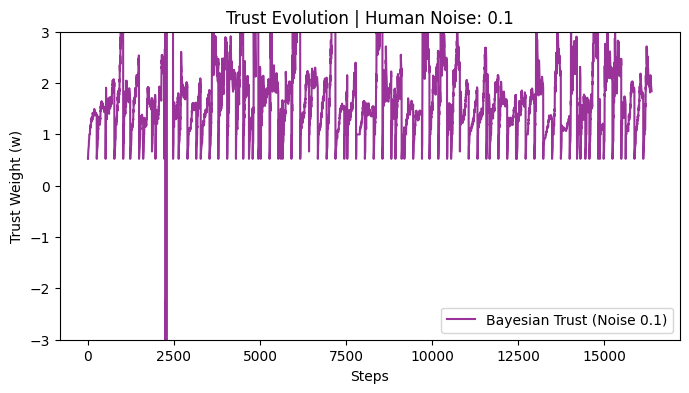

Training: Noise 0.5 | Mode naive
Training: Noise 0.5 | Mode bayesian


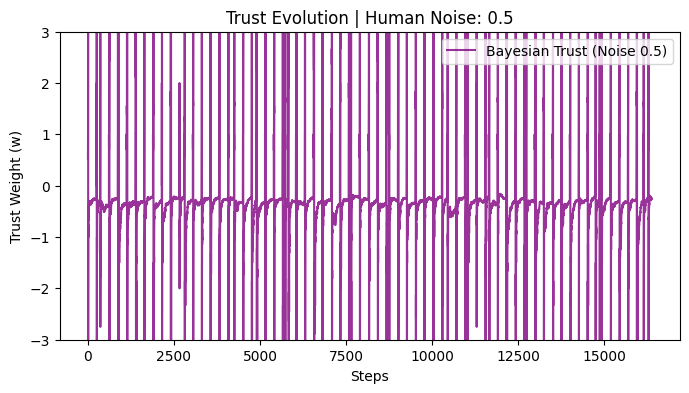

Training: Noise 0.9 | Mode naive
Training: Noise 0.9 | Mode bayesian


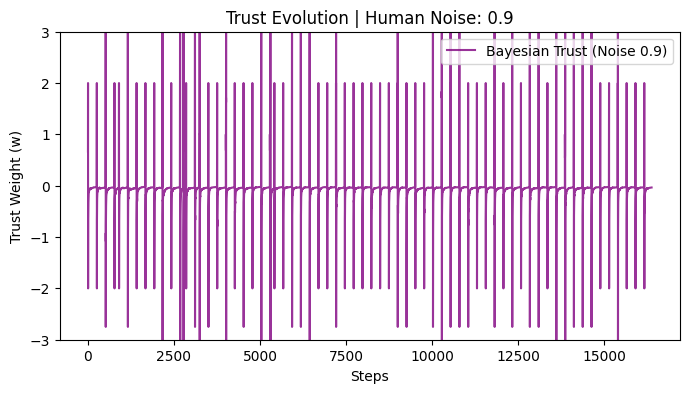


--- FINAL RESEARCH COMPARISON TABLE ---
Mode   bayesian  naive
Noise                 
0.1         1.0    0.9
0.5         0.0    0.0
0.9         0.0    0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
if __name__ == "__main__":
    results_df = run_full_benchmark()
    print("\n--- FINAL RESEARCH COMPARISON TABLE ---")
    print(results_df.pivot(index="Noise", columns="Mode", values="Score"))

### Previous Code Description (??)

In a standard MiniGrid environment, the reward is calculated using this formula:$$R = 1.0 - 0.9 \times \left( \frac{\text{steps}}{\text{max\_steps}} \right)$$If the agent reaches the goal quickly: The score is close to $1.0$.If the agent reaches the goal slowly: The score is closer to $0.1$.If the agent never reaches the goal: The score is $0.0$.

<b>BASELINE CODE DESCRIPTION - 3/17 PROGRESS</b>

Created benchmark suite to stress-test RLHF against varying degrees of teacher unreliability. At the center of this architecture is a Synthetic Human Teacher capable of providing dense rewards ($+0.1$ or $-0.1$) based on the agent's proximity to the goal, which you then systematically corrupted using Noise Injection. By modulating this noise across low (10%), medium (50%), and high (90%) levels, you created a spectrum of "teacher quality" to evaluate how different reward-integration strategies handle misinformation. This experiment was conducted within the MiniGrid-Empty-8x8-v0 environment, a grid-world where the agent must navigate to a green tile. 

Because MiniGrid provides sparse rewards ($1.0$ only upon completion), you utilized the environment's internal grid coordinates to perform "Physics Checks," calculating the Euclidean distance between the agent and the goal to verify if the teacher’s subjective feedback aligned with objective spatial progress. The core of your implementation lies in a Universal Research Wrapper that toggles between four distinct baseline logics to provide an "apples-to-apples" comparison:
- The Sparse baseline represents pure RL, ignoring the teacher entirely to establish a performance floor
- The Naive baseline represents standard RLHF, blindly summing environment and human rewards, which typically excels under low noise but crashes when the teacher lies
- The Fixed baseline acts as a skeptical mediator, consistently muffling the teacher's influence by a set factor (0.3)
- NOVEL Bayesian Reward Function: Use a Beta Distribution ($\alpha, \beta$) to maintain a running "Trust Score" ($w$). Treats the teacher as a noisy sensor; it rewards agreement between the teacher and the environment's physics by incrementing $\alpha$, while penalizing contradictions by incrementing $\beta$. The resulting trust score ($w = \alpha / (\alpha + \beta)$) dynamically scales the human's reward, effectively "muting" the teacher in real-time if their advice becomes statistically untrustworthy.

Beyond the reward logic, you implemented a Dynamic Goal Discovery mechanism. Since MiniGrid's procedural generation can hide the goal's location within the grid object, you wrote a scanner that locates the goal tile during every environment reset, ensuring the "Human" always has a ground-truth reference for its feedback.

This entire ecosystem was wrapped in a Benchmarking Loop that automatically trains a PPO (Proximal Policy Optimization) agent across every combination of noise and logic mode. This generated a comparison table that identifies exactly where your Bayesian model begins to outperform traditional, trust-based RLHF methods.